# Scoring Method -- Level 1 Analysis

Applying the **Will Robins Scoring Method (Level 1)** to my most recent **30 rounds**.

Change the `N` at the top of the setup cell to rescope the window.

## The Level 1 promise

Level 1 breaks every hole into two phases:

1. **Get inside the 100-yard scoring zone** -- full-swing phase. How many strokes did it take?
2. **Down in three from 100** -- short-game + putting phase. Get in the hole in <=3 strokes.

If you keep the ball in play AND achieve "down in three" on every hole, the math says your **worst possible score is bogey** -- regardless of par. Bogey golf on every hole = mid-teens handicap floor.

| Par | To-Zone target | In-Zone target | Bogey ceiling |
|-----|----------------|-----------------|---------------|
| 3   | <= 1           | <= 3            | 4 |
| 4   | <= 2           | <= 3            | 5 |
| 5   | <= 3           | <= 3            | 6 |

## Scorecard columns (per hole)

- **In Play** -- no penalty stroke this hole
- **To Zone** -- full-swing shots taken before ball first ended <=100 yd from pin
- **In Zone** -- total shots minus To Zone
- **Zone Reg** -- reached the zone in the "par-or-better" target strokes (3/4: <=1, 5: <=2)
- **D3** -- down-in-three from inside 100 (the headline stat)
- **Bogey Ceiling** -- met Robins' promise on this hole (Zone-in-bogey target AND D3)


In [1]:
# --- Setup ---
# The one knob: rerun with any N to expand/shrink the lookback window.
N = 30

import sys
from pathlib import Path
_p = Path.cwd().resolve()
while _p != _p.parent and not (_p / "arccos").is_dir():
    _p = _p.parent
if str(_p) not in sys.path:
    sys.path.insert(0, str(_p))
REPO = _p

import pandas as pd
import matplotlib.pyplot as plt

from arccos import load_arccos
from arccos.scoring_method import (
    select_last_n_rounds, compute_hole_metrics, format_scorecard_df,
    aggregate_summary, score_if_bogey_ceiling_held, derive_practice_priorities,
    compute_level_ladder, summarise_level_ladder, compute_gear_tally,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 140)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

data = load_arccos()
print(data.summary())


Arccos store: C:\Users\zfreitas\golf-data
  rounds:        50  date range 2023-08-10 to 2026-06-26
  holes:        599
  shots:       3012  GPS=yes
  clubs.csv:     39  (paired + unpaired, mixed)
  paired bag:    14  (authoritative — from clubs_v6.json)
  handicaps:     44  (per-round shot-type hcp series)
  courses:        9  (slope/rating from courses/*.json)
  round_dash:    50  (per-round SG splits, pace, hole scores)


## 1. Which 30 rounds are in scope?

Most recent N rounds by date. Table is shown newest-first for a quick eye-scan; downstream tables and charts are sorted chronologically (oldest -> newest) so the trend arc reads left-to-right.

In [2]:
last_n = select_last_n_rounds(data.rounds, N)
round_ids = last_n["round_id"].tolist()
print(f"Window: {last_n.date.min().date()} to {last_n.date.max().date()}  ({len(last_n)} rounds)")
print(f"Course mix: {last_n.course.value_counts().to_dict()}")
last_n[["date", "course", "holes", "score", "par", "score_to_par",
        "sg_total_broadie", "putts", "penalties"]]


Window: 2024-05-25 to 2026-06-26  (30 rounds)
Course mix: {'Twin Oaks GC': 24, 'Native Oaks GC': 3, 'Dos Osos GC': 1, 'Pala Mesa Resort': 1, 'Mt. Woodson Golf Club': 1}


,date,course,holes,score,par,score_to_par,sg_total_broadie,putts,penalties
0,2026-06-26,Twin Oaks GC,9,48,36,12,-11.47,18,0
1,2026-06-18,Twin Oaks GC,9,48,36,12,-12.35,20,2
2,2026-06-11,Twin Oaks GC,13,58,51,7,-7.02,24,0
3,2026-05-27,Twin Oaks GC,9,39,36,3,-3.77,18,0
4,2026-05-20,Twin Oaks GC,9,47,36,11,-10.93,18,3
5,2026-05-14,Twin Oaks GC,9,50,36,14,-12.37,15,6
6,2026-03-07,Dos Osos GC,18,100,72,28,-25.96,40,0
7,2025-08-21,Twin Oaks GC,9,49,36,13,-12.37,20,2
8,2025-08-15,Twin Oaks GC,9,56,36,20,-18.19,19,4
9,2025-08-07,Twin Oaks GC,9,48,36,12,-12.03,22,1


## 2. Per-hole metrics -- the raw substrate

One row per hole across the window. Everything downstream is a summary of this table.

In [3]:
hm = compute_hole_metrics(data.shots, data.holes, round_ids)
# Ensure chronological ordering everywhere; compute_hole_metrics already sorts
# by (date, round_id, hole_id) but this is defensive.
hm["date"] = pd.to_datetime(hm["date"])
hm = hm.sort_values(["date", "round_id", "hole_id"]).reset_index(drop=True)
print(f"{len(hm)} holes across {hm.round_id.nunique()} rounds")
hm.head()


324 holes across 30 rounds


,round_id,date,course,hole_id,par,shots,score_to_par,putts,penalties,in_play,strokes_to_zone,strokes_in_zone,zone_reached_in_reg,down_in_3,bogey_ceiling_met,blow_up
0,18782811,2024-05-25,Native Oaks GC,1,4,6,2,4,2,0,1,5,1,0,0,1
1,18782811,2024-05-25,Native Oaks GC,2,5,6,1,2,0,1,3,3,0,1,1,0
2,18782811,2024-05-25,Native Oaks GC,3,3,3,0,2,0,1,1,2,1,1,1,0
3,18782811,2024-05-25,Native Oaks GC,4,4,5,1,2,0,1,2,3,0,1,1,0
4,18782811,2024-05-25,Native Oaks GC,5,4,6,2,2,0,1,2,4,0,0,0,1


## 3. Aggregate Level 1 dashboard

In [4]:
agg = aggregate_summary(hm)
agg.to_frame()


,Metric,Value
0,Rounds,30
1,Holes played,324
2,Score vs par (total),1643 / 1294 (+349)
3,In-play %,88%
4,Zone reached in reg %,34%
5,Down-in-3 rate,69% <-- HEADLINE
6,Bogey-ceiling %,61%
7,Blow-up holes (dbl+),103 of 324 (32%)
8,Avg putts / hole,2.16


### By par

In [5]:
agg.by_par


,holes,avg_score,in_play_pct,zone_reg_pct,d3_rate,bogey_ceiling_pct,avg_to_zone,avg_in_zone,avg_putts,blow_up_pct
par,,,,,,,,,,
3,73,4.01,0.84,0.95,0.79,0.74,1.05,2.96,2.16,0.26
4,180,5.16,0.90,0.14,0.64,0.55,1.98,3.18,2.24,0.36
5,71,5.93,0.89,0.21,0.72,0.65,2.92,3.01,1.96,0.28


**How to read this table:**

- `zone_reg_pct` = % of holes where you reached 100 yd in "par-target" strokes.
- `d3_rate` = % of holes where, once inside 100, you got in the hole in <=3.
- `bogey_ceiling_pct` = % of holes where you met Robins' full promise (par or bogey).
- If `zone_reg_pct` is much lower than `d3_rate`, the leak is full-swing (not short game).
- If `d3_rate` is much lower than `zone_reg_pct`, the leak is inside 100.


## 3b. Level ladder -- L1 through L4 achievement

**Fixed baselines (per Robins).** Each hole either did or didn't reach that
distance-to-pin line by regulation stroke (par-2). Achievement nests:
L4 ⊂ L3 ⊂ L2 ⊂ L1, so counts drop as the target tightens.

- **L1** -- inside 100 yd in ≤ par-2 strokes
- **L2** -- inside 50 yd in ≤ par-2 strokes
- **L3** -- inside 25 yd in ≤ par-2 strokes
- **L4** -- on the green in ≤ par-2 strokes (traditional GIR proxy: non-putt shots ≤ par-2 AND ≥1 putt)

The gap between L1 and L4 is where the "full-swing tightness" question lives:
a lot of L1 hits with few L4 = you're getting close but not on. Practice
target = precision, not distance.


In [6]:
ladder = compute_level_ladder(data.shots, data.holes, round_ids)
ladder_summary = summarise_level_ladder(ladder)
ladder_summary


,Level,Definition,Holes achieved,Rate
0,L1,L1 (inside 100 yd in reg),289 / 324,89%
1,L2,L2 (inside 50 yd in reg),229 / 324,71%
2,L3,L3 (inside 25 yd in reg),158 / 324,49%
3,L4,L4 / GIR (on green in reg),100 / 324,31%


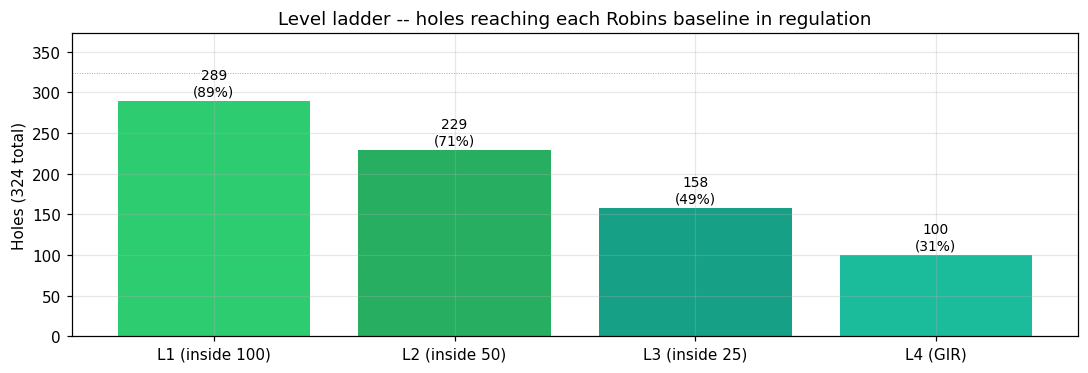

In [7]:
fig, ax = plt.subplots(figsize=(10, 3.5))
level_labels = ["L1 (inside 100)", "L2 (inside 50)", "L3 (inside 25)", "L4 (GIR)"]
level_counts = [int(ladder["l1_reg"].sum()), int(ladder["l2_reg"].sum()),
                int(ladder["l3_reg"].sum()), int(ladder["l4_reg"].sum())]
total = len(ladder)
bars = ax.bar(level_labels, level_counts,
              color=["#2ecc71", "#27ae60", "#16a085", "#1abc9c"])
for bar, cnt in zip(bars, level_counts):
    pct = cnt / total if total else 0
    ax.text(bar.get_x() + bar.get_width()/2, cnt + total*0.01,
            f"{cnt}\n({pct:.0%})", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, total * 1.15)
ax.set_ylabel(f"Holes ({total} total)")
ax.set_title("Level ladder -- holes reaching each Robins baseline in regulation")
ax.axhline(total, color="#95a5a6", linewidth=0.6, linestyle=":")
plt.tight_layout()


## 3c. Inferred Gear tally

**Caveat: this is a heuristic proxy for shot INTENT.** True Robins gears are
a shot-by-shot decision (attack aggressively / play safe) that Arccos does
not record. This tally buckets non-putt shots by *start distance to pin*,
which is a rough stand-in for the club/effort you likely used but does not
capture intent — a G0 punch-out from behind a tree at 150 yd will be tagged
G3 here.

Use for order-of-magnitude context (how many long shots vs scoring shots per
round) — not for grading gear decisions. That grading only works with the
printed scorecard where you record actual in-the-moment intent.


In [8]:
gears = compute_gear_tally(data.shots, round_ids)
gears


,Gear,Definition (inferred by start distance),Shots,Rate
0,G4,Long full swing / driver / 3W (start >180 yd),388,24%
1,G3,Mid iron / hybrid approach (100-180 yd),252,15%
2,G2,Wedge / scoring full swing (30-100 yd),174,11%
3,G1,"Chip / pitch / short shot (≤30 yd, non-putt)",129,8%
4,G0,Recovery / punch-out (not inferrable...,0,0%
5,Putt,On-green stroke (separate category),700,43%


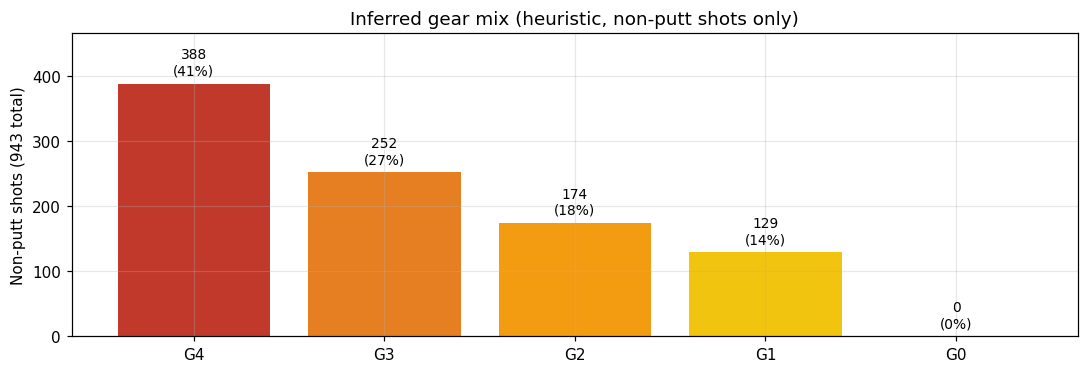

In [9]:
non_putt_only = gears[gears["Gear"].isin(["G4", "G3", "G2", "G1", "G0"])].copy()
fig, ax = plt.subplots(figsize=(10, 3.5))
bars = ax.bar(non_putt_only["Gear"], non_putt_only["Shots"],
              color=["#c0392b", "#e67e22", "#f39c12", "#f1c40f", "#95a5a6"])
total_np = int(non_putt_only["Shots"].sum())
for bar, cnt in zip(bars, non_putt_only["Shots"]):
    pct = cnt / total_np if total_np else 0
    ax.text(bar.get_x() + bar.get_width()/2, cnt + total_np*0.01,
            f"{cnt}\n({pct:.0%})", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, (max(non_putt_only["Shots"]) if total_np else 1) * 1.2)
ax.set_ylabel(f"Non-putt shots ({total_np} total)")
ax.set_title("Inferred gear mix (heuristic, non-putt shots only)")
plt.tight_layout()


## 4. Practice priorities -- Robins-lens read

In [10]:
for note in derive_practice_priorities(agg):
    print(" -", note)
    print()


 - GET-TO-ZONE LEAK: only 34% of holes reached 100 yd in regulation. Full-swing distance/direction is the gate -- practice range with target commitment, not the short-game area.

 - BLOW-UP RATE: 32% of holes are dbl+ (target <=15%). On-course rule for next round: after any bad shot, drop your target one level (Level 4 GIR intent -> Level 1 get-inside-100 intent). Kill the compounding.



## 5. The Robins Promise -- actual vs bogey-ceiling counterfactual

**How many strokes would you have saved over the last 30 rounds if you had achieved bogey-ceiling on every hole?**  
(Par when the ceiling was met, bogey when it wasn't -- no reward for pars/birdies above the ceiling; this is a *worst-case* projection.)

In [11]:
proj = score_if_bogey_ceiling_held(hm).copy()
proj["date"] = pd.to_datetime(proj["date"])
proj = proj.sort_values("date").reset_index(drop=True)
proj["date_str"] = proj["date"].dt.strftime("%Y-%m-%d")
print(f"Total actual: {proj.actual.sum()}   Total ceiling: {proj.ceiling.sum()}   "
      f"Strokes available: {proj.strokes_saved.sum()}")
proj[["date_str", "course", "holes", "par", "actual", "ceiling", "strokes_saved"]]


Total actual: 1643   Total ceiling: 1419   Strokes available: 224


,date_str,course,holes,par,actual,ceiling,strokes_saved
0,2024-05-25,Native Oaks GC,18,72,93,81,12
1,2024-05-30,Twin Oaks GC,9,36,44,39,5
2,2024-05-31,Twin Oaks GC,4,16,19,17,2
3,2024-06-07,Native Oaks GC,18,72,92,80,12
4,2024-06-11,Twin Oaks GC,9,36,45,40,5
5,2024-07-25,Twin Oaks GC,9,36,44,40,4
6,2024-08-01,Twin Oaks GC,9,36,44,39,5
7,2024-08-15,Twin Oaks GC,9,36,45,39,6
8,2024-08-22,Twin Oaks GC,9,36,51,43,8
9,2024-08-29,Twin Oaks GC,9,36,48,41,7


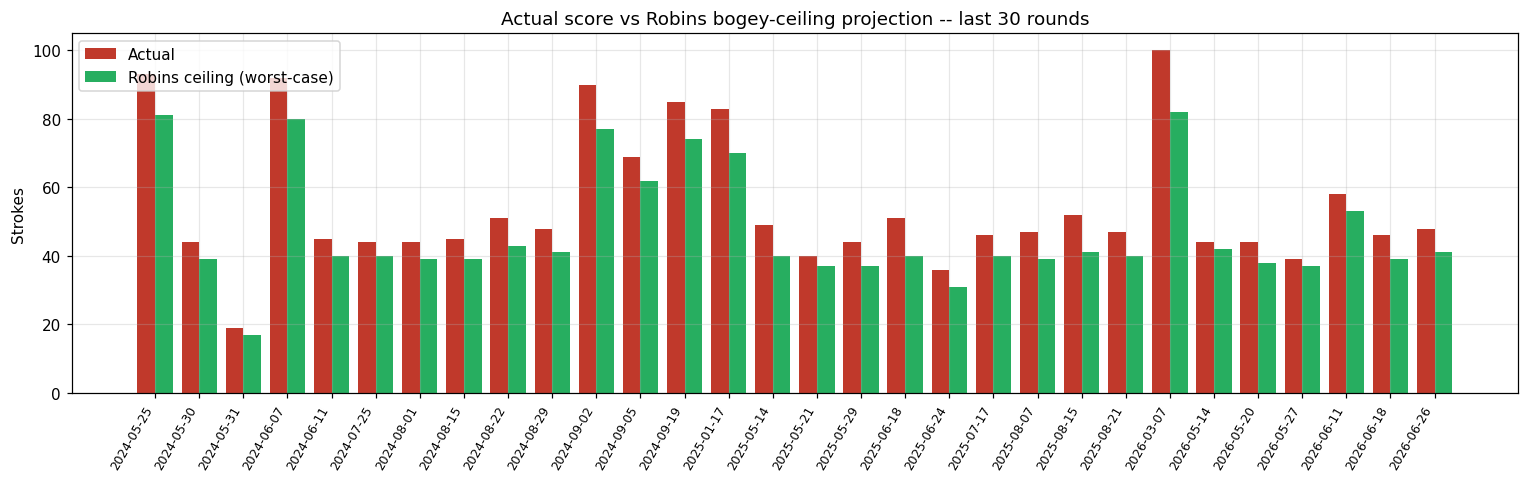

In [12]:
fig, ax = plt.subplots(figsize=(14, 4.5))
x = range(len(proj))
w = 0.4
ax.bar([i - w/2 for i in x], proj["actual"],  w, label="Actual",                        color="#c0392b")
ax.bar([i + w/2 for i in x], proj["ceiling"], w, label="Robins ceiling (worst-case)",   color="#27ae60")
ax.set_xticks(list(x))
ax.set_xticklabels(proj["date"].dt.strftime("%Y-%m-%d"), rotation=60, ha="right", fontsize=8)
ax.set_ylabel("Strokes")
ax.set_title(f"Actual score vs Robins bogey-ceiling projection -- last {len(proj)} rounds")
ax.legend(loc="upper left")
plt.tight_layout()


## 6. Per-round scorecards

All 30 rounds, oldest first (matches the chronological arc of the charts above). Each card includes round totals below the hole grid.

In [13]:
for rid, sub in hm.groupby("round_id", sort=False):
    r_meta = last_n[last_n.round_id == rid].iloc[0]
    date_s = pd.to_datetime(r_meta["date"]).strftime("%Y-%m-%d")
    card = format_scorecard_df(sub)
    print(f"=== {date_s}  {r_meta['course']}  ({int(r_meta['holes'])} holes, {int(r_meta['score'])} / {int(r_meta['par'])}) ===")
    print(card.to_string(index=False))
    totals = {
        "Holes": len(sub),
        "In Play":       f"{int(sub['in_play'].sum())}/{len(sub)}",
        "Zone Reg":      f"{int(sub['zone_reached_in_reg'].sum())}/{len(sub)}",
        "D3":            f"{int(sub['down_in_3'].sum())}/{len(sub)}",
        "Bogey Ceiling": f"{int(sub['bogey_ceiling_met'].sum())}/{len(sub)}",
        "Blow-ups":      int(sub["blow_up"].sum()),
    }
    print("Round totals:", "  ".join(f"{k}={v}" for k, v in totals.items()))
    print()


=== 2024-05-25  Native Oaks GC  (18 holes, 100 / 72) ===
 Hole  Par  Score  +/- In Play  To Zone  In Zone Zone Reg D3 Bogey Ceiling  Putts  Pen
    1    4      6    2       N        1        5        Y  N             N      4    2
    2    5      6    1       Y        3        3        N  Y             Y      2    0
    3    3      3    0       Y        1        2        Y  Y             Y      2    0
    4    4      5    1       Y        2        3        N  Y             Y      2    0
    5    4      6    2       Y        2        4        N  N             N      2    0
    6    4      5    1       Y        2        3        N  Y             Y      3    0
    7    4      5    1       Y        1        4        Y  N             N      3    0
    8    3      5    2       N        1        4        Y  N             N      3    1
    9    5      6    1       Y        2        4        Y  N             N      3    0
   10    4      6    2       Y        1        5        Y  N             

## 7. Trend across the 30 rounds

All four Level 1 metrics plotted against time, with a dashed **linear trend line** overlaid for each series. Look for regime shifts (not point-to-point wiggle) and read the legend for total change in percentage points across the window (positive = getting better).

In [14]:
per_round = (hm.groupby(["round_id", "date"])
                .agg(in_play_pct=("in_play", "mean"),
                     zone_reg_pct=("zone_reached_in_reg", "mean"),
                     d3_rate=("down_in_3", "mean"),
                     bogey_ceiling_pct=("bogey_ceiling_met", "mean"),
                     blow_up_pct=("blow_up", "mean"),
                     holes=("hole_id", "count"))
                .reset_index())
per_round["date"] = pd.to_datetime(per_round["date"])
per_round = per_round.sort_values("date").reset_index(drop=True)
per_round["date_str"] = per_round["date"].dt.strftime("%Y-%m-%d")
per_round


,round_id,date,in_play_pct,zone_reg_pct,d3_rate,bogey_ceiling_pct,blow_up_pct,holes,date_str
0,18782811,2024-05-25,0.777778,0.500000,0.500000,0.500000,0.333333,18,2024-05-25
1,18870374,2024-05-30,0.888889,0.222222,0.666667,0.666667,0.333333,9,2024-05-30
2,18871066,2024-05-31,1.000000,0.500000,1.000000,0.750000,0.250000,4,2024-05-31
3,19009362,2024-06-07,1.000000,0.444444,0.611111,0.555556,0.333333,18,2024-06-07
4,19091146,2024-06-11,0.666667,0.444444,0.555556,0.555556,0.444444,9,2024-06-11
5,19886810,2024-07-25,0.777778,0.333333,0.666667,0.555556,0.444444,9,2024-07-25
6,20014063,2024-08-01,0.777778,0.333333,0.777778,0.666667,0.222222,9,2024-08-01
7,20257957,2024-08-15,0.888889,0.444444,0.888889,0.666667,0.333333,9,2024-08-15
8,20378618,2024-08-22,1.000000,0.444444,0.333333,0.222222,0.555556,9,2024-08-22
9,20497312,2024-08-29,1.000000,0.222222,0.555556,0.444444,0.555556,9,2024-08-29


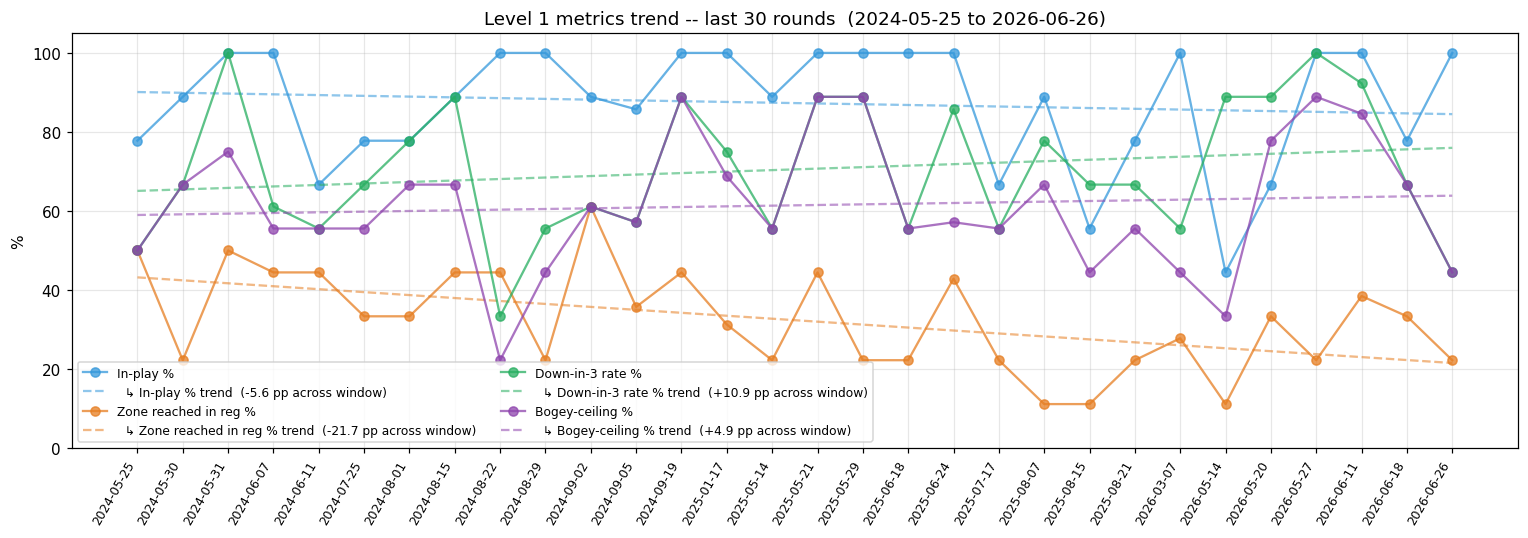

In [15]:
import numpy as np

fig, ax = plt.subplots(figsize=(14, 5))
labels = per_round["date"].dt.strftime("%Y-%m-%d")
x_num = np.arange(len(per_round))

series = [
    ("In-play %",              per_round["in_play_pct"] * 100,       "#3498db"),
    ("Zone reached in reg %",  per_round["zone_reg_pct"] * 100,      "#e67e22"),
    ("Down-in-3 rate %",       per_round["d3_rate"] * 100,           "#27ae60"),
    ("Bogey-ceiling %",        per_round["bogey_ceiling_pct"] * 100, "#8e44ad"),
]

for label, y, color in series:
    ax.plot(labels, y, marker="o", label=label, color=color, alpha=0.75)
    # Linear trend line (dashed, same colour). Skip if all-NaN or singleton.
    y_valid = y.dropna()
    if len(y_valid) >= 2:
        m, b = np.polyfit(x_num[y.notna().values], y_valid.values, 1)
        trend_y = m * x_num + b
        slope_pp = m * (len(per_round) - 1)  # total change across window in pp
        ax.plot(labels, trend_y, linestyle="--", color=color, alpha=0.55,
                label=f"  ↳ {label} trend  ({slope_pp:+.1f} pp across window)")

ax.set_ylim(0, 105)
ax.set_ylabel("%")
ax.set_title(f"Level 1 metrics trend -- last {len(per_round)} rounds  ({per_round.date.min().date()} to {per_round.date.max().date()})")
ax.tick_params(axis="x", rotation=60)
for tick in ax.get_xticklabels():
    tick.set_horizontalalignment("right")
    tick.set_fontsize(8)
ax.legend(loc="lower left", fontsize=8, ncol=2)
plt.tight_layout()


## 8. Export to Excel

`outputs/scoring_method_L1.xlsx` -- summary sheet + one printable card per round (30 round sheets, sorted chronologically by name).

In [16]:
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

OUT = REPO / "outputs" / "scoring_method_L1.xlsx"
OUT.parent.mkdir(exist_ok=True)

wb = Workbook()

bold = Font(bold=True)
header_fill = PatternFill("solid", fgColor="2c3e50")
header_font = Font(bold=True, color="FFFFFF")
thin = Side(style="thin", color="BBBBBB")
border = Border(left=thin, right=thin, top=thin, bottom=thin)

# --- Summary sheet -------------------------------------------------
ws = wb.active
ws.title = "Summary"

ws["A1"] = f"Scoring Method Level 1 -- Last {N} Rounds"
ws["A1"].font = Font(bold=True, size=14)
ws["A2"] = f"Window: {last_n.date.min().date()} to {last_n.date.max().date()}"
ws["A3"] = f"Generated: {pd.Timestamp.today().strftime('%Y-%m-%d')}"

ws["A5"] = "Headline metrics"
ws["A5"].font = bold
start = 6
for i, (k, v) in enumerate(agg.to_frame().itertuples(index=False), start=start):
    ws.cell(row=i, column=1, value=k).font = bold
    ws.cell(row=i, column=2, value=v)

ws.cell(row=ws.max_row + 2, column=1, value="By par").font = bold
by_par_start = ws.max_row + 1
bp = agg.by_par.reset_index()
for col, header in enumerate(bp.columns, start=1):
    cell = ws.cell(row=by_par_start, column=col, value=header)
    cell.font = header_font
    cell.fill = header_fill
    cell.alignment = Alignment(horizontal="center")
for r_off, row in enumerate(bp.itertuples(index=False), start=1):
    for col, val in enumerate(row, start=1):
        cell = ws.cell(row=by_par_start + r_off, column=col, value=val)
        cell.border = border
        if isinstance(val, float):
            cell.number_format = "0.00"

ws.cell(row=ws.max_row + 2, column=1, value="Practice priorities (Robins-lens read)").font = bold
for note in derive_practice_priorities(agg):
    ws.cell(row=ws.max_row + 1, column=1, value=note).alignment = Alignment(wrap_text=True, vertical="top")

ws.cell(row=ws.max_row + 2, column=1, value="Robins Promise projection (actual vs bogey-ceiling)").font = bold
proj_start = ws.max_row + 1
proj_out = proj[["date_str", "course", "holes", "par", "actual", "ceiling", "strokes_saved"]].rename(columns={"date_str": "date"})
for col, header in enumerate(proj_out.columns, start=1):
    cell = ws.cell(row=proj_start, column=col, value=header)
    cell.font = header_font
    cell.fill = header_fill
for r_off, row in enumerate(proj_out.itertuples(index=False), start=1):
    for col, val in enumerate(row, start=1):
        cell = ws.cell(row=proj_start + r_off, column=col, value=val)
        cell.border = border

# Totals row under projection
totals_row = ws.max_row + 1
ws.cell(row=totals_row, column=1, value="TOTAL").font = bold
ws.cell(row=totals_row, column=3, value=int(proj_out["holes"].sum())).font = bold
ws.cell(row=totals_row, column=4, value=int(proj_out["par"].sum())).font = bold
ws.cell(row=totals_row, column=5, value=int(proj_out["actual"].sum())).font = bold
ws.cell(row=totals_row, column=6, value=int(proj_out["ceiling"].sum())).font = bold
ws.cell(row=totals_row, column=7, value=int(proj_out["strokes_saved"].sum())).font = bold

for col_idx in range(1, 12):
    ws.column_dimensions[get_column_letter(col_idx)].width = 22

# --- Per-round scorecards (chronological sheet order) -------------
for rid, sub in hm.groupby("round_id", sort=False):
    r_meta = last_n[last_n.round_id == rid].iloc[0]
    date_s = pd.to_datetime(r_meta["date"]).strftime("%Y-%m-%d")
    sheet = wb.create_sheet(title=date_s)
    sheet.cell(row=1, column=1, value=f"{date_s} -- {r_meta['course']}  "
                                       f"({int(r_meta['holes'])} holes, "
                                       f"score {int(r_meta['score'])}/{int(r_meta['par'])})").font = Font(bold=True, size=13)

    card = format_scorecard_df(sub)
    header_row = 3
    for col, header in enumerate(card.columns, start=1):
        c_ = sheet.cell(row=header_row, column=col, value=header)
        c_.font = header_font
        c_.fill = header_fill
        c_.alignment = Alignment(horizontal="center")
        c_.border = border
    for r_off, row in enumerate(card.itertuples(index=False), start=1):
        for col, val in enumerate(row, start=1):
            cell = sheet.cell(row=header_row + r_off, column=col, value=val)
            cell.alignment = Alignment(horizontal="center")
            cell.border = border
            if card.columns[col - 1] in ("In Play", "Zone Reg", "D3", "Bogey Ceiling"):
                if val == "Y":
                    cell.fill = PatternFill("solid", fgColor="D5F5E3")
                elif val == "N":
                    cell.fill = PatternFill("solid", fgColor="FADBD8")

    totals_row = header_row + len(card) + 2
    sheet.cell(row=totals_row, column=1, value="Round totals").font = bold
    round_totals = [
        ("Holes",         len(sub)),
        ("In Play",       f"{int(sub['in_play'].sum())}/{len(sub)}"),
        ("Zone Reg",      f"{int(sub['zone_reached_in_reg'].sum())}/{len(sub)}"),
        ("D3",            f"{int(sub['down_in_3'].sum())}/{len(sub)}"),
        ("Bogey Ceiling", f"{int(sub['bogey_ceiling_met'].sum())}/{len(sub)}"),
        ("Blow-ups",      int(sub['blow_up'].sum())),
    ]
    for i, (k, v) in enumerate(round_totals):
        sheet.cell(row=totals_row + 1 + i, column=1, value=k).font = bold
        sheet.cell(row=totals_row + 1 + i, column=2, value=v)

    for col_idx in range(1, len(card.columns) + 1):
        sheet.column_dimensions[get_column_letter(col_idx)].width = 12

# Reorder tabs: Summary first, then round sheets already in chronological order.
wb.save(OUT)
print(f"Wrote {OUT}  ({len(wb.sheetnames)} sheets)")


Wrote C:\Users\zfreitas\OneDrive - Viasat, Inc\Documents\Claude\Golf_Analysis\outputs\scoring_method_L1.xlsx  (31 sheets)


---

## What Level 1 says over this window

Read the summary + practice-priorities cells above for the auto-generated Robins-lens read. With a wider window (30 rounds vs 5), the by-par table and D3 rate are more stable estimates -- the 5-round snapshot had 49 holes, this one has hundreds.

### How this analysis complements the SG-based diagnostics

The existing `tasks/todo.md` diagnostics (short putts 5-12 ft, iron strike, 125-150 yd approach) isolate *technique* leaks by shot type. Level 1 asks a different question: **on any given hole, which phase is bleeding strokes -- full-swing or short-game?** Both reads are simultaneously true; they answer different questions. The Robins framing is more actionable for on-course decision-making ("after a bad shot, revert to Level 1 intent -- kill the compounding").

### Next levels

- **Level 2 (inside 50 yd)** -- same shape, zone shrinks. Target: down-in-2 from 50.
- **Level 3 (inside 25 yd)** -- up-and-down conversion, chip proximity.
- **Level 4 (on the green)** -- GIR rate, first-putt proximity, 3-putt avoidance.

Change `N` at the top of the setup cell to rescope the window.
